In [1]:
import torch
import numpy as np
import matplotlib

In [48]:
import os
from pathlib import Path
import json
import numpy as np
import torch
import torch.nn as nn
import gym
import neurogym as ngym
from neurogym.wrappers import ScheduleEnvs
from neurogym.utils import scheduler
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from neurogym.wrappers.block import MultiEnvs
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib
from matplotlib.colors import ListedColormap
import copy
import torch.nn.functional as F

/Users/ismaelrobles-razzaq/Desktop/research/.venv/lib/python3.11/site-packages/gym/envs/registration.py:396: UserWarning: WARN: The `registry.all` method is deprecated. Please use `registry.values` instead.
  logger.warn(


In [2]:
import train
import task
import model
import tools
import RNN_rate_dynamics

/Users/ismaelrobles-razzaq/Desktop/research/RNN_multitask/multitask/task.py:1591: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if rule is 'testinit':


In [3]:
hp, log, optimizer = train.set_hyperparameters(
    model_dir='debug',
    hp={'learning_rate': 0.001},
    ruleset='all',
)

In [4]:
run_model = model.Run_Model(hp, RNN_rate_dynamics.RNNLayer)


In [5]:
run_model.load_state_dict(torch.load('../run_model_state.pth'))
run_model.model.eval()  # Set the model to evaluation mode

/var/folders/9c/4b964bn507zc652npm2l2ch80000gn/T/ipykernel_53056/1411001053.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  run_model.load_state_dict(torch.load('../run_

Model(
  (rnn): RNNLayer(
    (rnncell): RNNCell(
      (nonlinearity): RecursiveScriptModule(original_name=ReLU)
    )
  )
  (readout): Linear(in_features=256, out_features=33, bias=False)
)

Fig 1 d

In [1]:

def generate_dm1_trials(stim_diff_range, stim_times, n_trials_per_condition):
    trials = []
    for stim_diff in stim_diff_range:
        for stim_time in stim_times:
            for _ in range(n_trials_per_condition):
                stim1 = np.random.rand()
                stim2 = stim1 - stim_diff
                trials.append({
                    'stim1': stim1,
                    'stim2': stim2,
                    'stim_time': stim_time
                })
    return trials

In [7]:
run_model.hp

{'batch_size_train': 64,
 'batch_size_test': 512,
 'in_type': 'normal',
 'rnn_type': 'LeakyRNN',
 'use_separate_input': False,
 'loss_type': 'lsq',
 'optimizer': 'adam',
 'activation': 'relu',
 'tau': 100,
 'dt': 20,
 'alpha': 0.2,
 'sigma_rec': 0.05,
 'sigma_x': 0.01,
 'w_rec_init': 'randortho',
 'l1_h': 0,
 'l2_h': 0,
 'l1_weight': 0,
 'l2_weight': 0,
 'l2_weight_init': 0,
 'p_weight_train': None,
 'target_perf': 1.0,
 'n_eachring': 32,
 'num_ring': 2,
 'n_rule': 20,
 'rule_start': 65,
 'n_input': 85,
 'n_output': 33,
 'n_rnn': 256,
 'ruleset': 'all',
 'save_name': 'test',
 'learning_rate': 0.001,
 'c_intsyn': 0,
 'ksi_intsyn': 0,
 'seed': 0,
 'rng': RandomState(MT19937) at 0x106D86C40,
 'model_dir': 'debug',
 'max_steps': 10000000.0,
 'display_step': 500,
 'rich_output': False,
 'decay': 0.8187307530779818,
 'rule_trains': ['fdgo',
  'reactgo',
  'delaygo',
  'fdanti',
  'reactanti',
  'delayanti',
  'dm1',
  'dm2',
  'contextdm1',
  'contextdm2',
  'multidm',
  'delaydm1',
  'delay

Task variance figs

In [35]:
# playground
#for rule in hp['rules']:
rule = 'dm1'
_, _, _, h, trial = run_model(rule=rule, mode='test')
print(h.shape)
trial.epochs # time, batch, units

(125, 100, 256)


(125, 100, 256)

In [41]:
def generate_multiple_trials(run_model, rule):
    all_h = []
    #all_epochs = []
    #for _ in range(n_trials):
    _, _, _, h, trial = run_model(rule=rule, mode='test')
        #all_h.append(h)#.detach().cpu().numpy())
        #all_epochs.append(trial.epochs)
    return h, trial.epochs  # shape: (time, trials, units)

In [40]:
def compute_task_variance(h_all, epochs):
    # Exclude fixation period
    fix_end = epochs['fix1'][1]
    h_task = h[fix_end:, :, :]  # shape: (time, trials, units)
    print(h_task.shape)
    # Compute variance across trials for each timestep and unit
    var_over_trials = np.var(h_task, axis=1)  # shape: (time, units)
    print(var_over_trials.shape)
    
    # Average variance over time
    return np.mean(var_over_trials, axis=0)  # shape: (units,)

In [39]:
def compute_all_task_variances(run_model, rules):
    h_var_all = []
    for rule in rules:
        h_task, epochs = generate_multiple_trials(run_model, rule)
        h_var = compute_task_variance(h_task, epochs)
        h_var_all.append(h_var)
    return np.array(h_var_all).T  # shape: (units, tasks)

In [ ]:
h_var_all = compute_all_task_variances(run_model, hp['rules'])
h_var_all.shape

In [74]:
summed_variances = np.sum(h_var_all, axis=1)

threshold = 1e-3
active_units_mask = summed_variances > threshold
filtered_task_variance_matrix = h_var_all[active_units_mask, :]
filtered_task_variance_matrix.shape


(192, 20)

In [87]:
np.max(filtered_task_variance_matrix, axis=0)

array([0.05001447, 0.18341988, 0.05001447, 0.05001447, 0.18341988,
       0.05001447, 0.05001447, 0.05001447, 0.05001447, 0.05001447,
       0.05001447, 0.05001447, 0.05001447, 0.05001447, 0.05001447,
       0.05001447, 0.05001447, 0.05001447, 0.05001447, 0.05001447],
      dtype=float32)

In [88]:
h_normvar_all = filtered_task_variance_matrix / np.max(filtered_task_variance_matrix, axis=0, keepdims=True)
h_normvar_all.shape

(192, 20)

In [114]:
# Define range of clusters to try
n_clusters_range = range(2, 30)  # Increased upper limit to 30
#n_clusters_range = range(8, 30) # will optimize to 2 clusters if allowed

# Store scores and labels
silhouette_scores = []
labels_list = []

# Perform clustering for different numbers of clusters
for n_clusters in n_clusters_range:
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    labels = kmeans.fit_predict(h_normvar_all)  # Transpose to cluster units
    score = silhouette_score(h_normvar_all, labels)

    silhouette_scores.append(score)
    labels_list.append(labels)


NameError: name 'n_cluster' is not defined

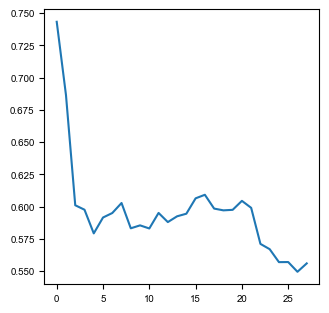

In [115]:

"""Plot the score by the number of clusters."""
fig = plt.figure(figsize=(5, 5))
ax = fig.add_axes([0.3, 0.3, 0.55, 0.55])
plt.plot(silhouette_scores)
ax.set_title('Chosen number of clusters: {:d}'.format(n_cluster),
                 fontsize=7)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.set_ylim([0, 0.32])

plt.show()

In [108]:

# Find the optimal number of clusters
optimal_n_clusters = n_clusters_range[np.argmax(silhouette_scores)]

# Get the labels for the optimal number of clusters
optimal_labels = labels_list[np.argmax(silhouette_scores)]

print(f"Optimal number of clusters: {optimal_n_clusters}")

Optimal number of clusters: 3


In [106]:
silhouette_scores

[np.float32(0.6864042),
 np.float32(0.6009798),
 np.float32(0.59751207),
 np.float32(0.57915896),
 np.float32(0.5914706),
 np.float32(0.5949469),
 np.float32(0.6027291),
 np.float32(0.5831085),
 np.float32(0.58538246),
 np.float32(0.5829714),
 np.float32(0.59503365),
 np.float32(0.5879236),
 np.float32(0.59240985),
 np.float32(0.5944188),
 np.float32(0.606345),
 np.float32(0.609104),
 np.float32(0.59839636),
 np.float32(0.59702605),
 np.float32(0.59742874),
 np.float32(0.6043908),
 np.float32(0.598975),
 np.float32(0.5710097),
 np.float32(0.5669102),
 np.float32(0.55686265),
 np.float32(0.5569281),
 np.float32(0.5493832),
 np.float32(0.5558788)]